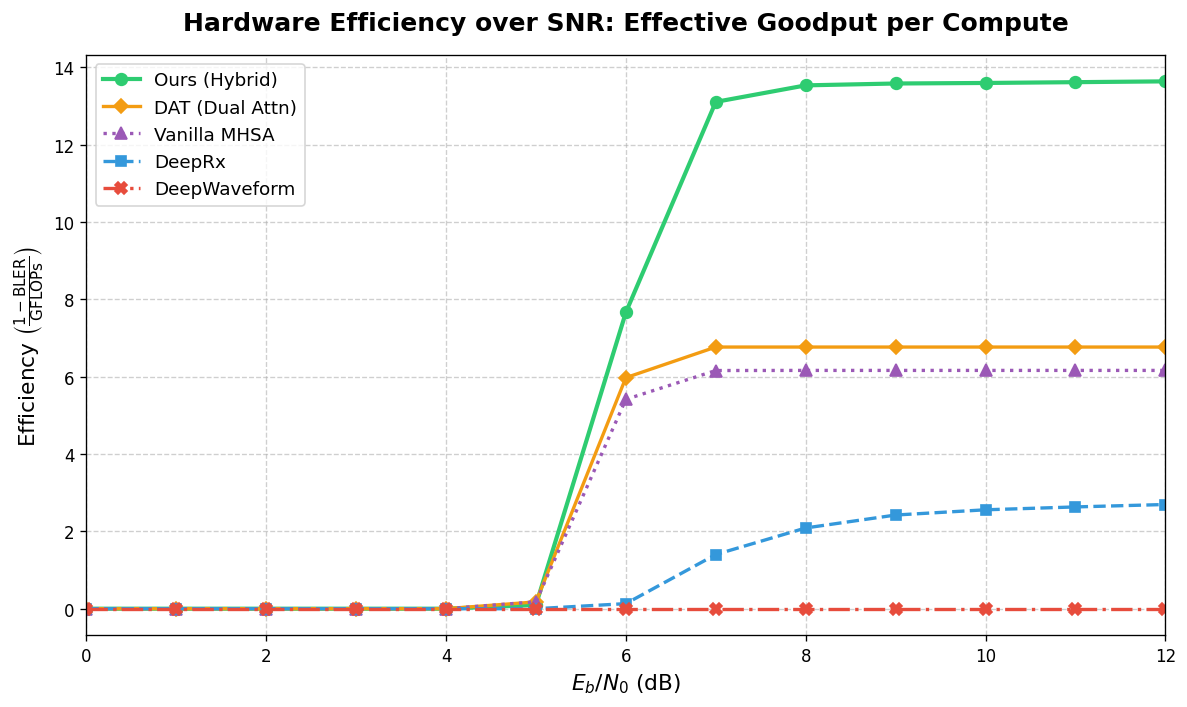

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# DYNAMIC HARDWARE EFFICIENCY: GOODPUT PER GIGAFLOP OVER SNR
# ==============================================================================

ebno_db = np.arange(0, 13)

# FLOPs (in Millions) -> Converted to GFLOPs for a cleaner metric scale
gflops = {
    'Ours': 72.57 / 1000,
    'DAT': 147.81 / 1000,
    'MHSA': 162.30 / 1000,
    'DeepRx': 343.72 / 1000,
    'DeepWaveform': 295.99 / 1000
}

# BLER Arrays extracted from your logs
bler_ours = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 0.993, 0.444, 0.049, 0.018, 0.0145, 0.0135, 0.012, 0.0105])
bler_dat = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 0.974, 0.117, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
bler_mhsa = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 0.971, 0.1215, 0.0005, 0.0, 0.0, 0.0, 0.0, 0.0])
bler_deeprx = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.955, 0.5185, 0.2825, 0.1675, 0.121, 0.0955, 0.074])
bler_deepwaveform = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0])

# Calculate Efficiency: (1 - BLER) / GFLOPs
eff_ours = (1 - bler_ours) / gflops['Ours']
eff_dat = (1 - bler_dat) / gflops['DAT']
eff_mhsa = (1 - bler_mhsa) / gflops['MHSA']
eff_deeprx = (1 - bler_deeprx) / gflops['DeepRx']
eff_deepwaveform = (1 - bler_deepwaveform) / gflops['DeepWaveform']

plt.figure(figsize=(10, 6), dpi=120)

plt.plot(ebno_db, eff_ours, label='Ours (Hybrid)', color='#2ecc71', marker='o', linestyle='-', linewidth=2.5, markersize=7)
plt.plot(ebno_db, eff_dat, label='DAT (Dual Attn)', color='#f39c12', marker='D', linestyle='-', linewidth=2, markersize=6)
plt.plot(ebno_db, eff_mhsa, label='Vanilla MHSA', color='#9b59b6', marker='^', linestyle=':', linewidth=2, markersize=7)
plt.plot(ebno_db, eff_deeprx, label='DeepRx', color='#3498db', marker='s', linestyle='--', linewidth=2, markersize=6)
plt.plot(ebno_db, eff_deepwaveform, label='DeepWaveform', color='#e74c3c', marker='X', linestyle='-.', linewidth=2, markersize=7)

# Formatting
plt.title("Hardware Efficiency over SNR: Effective Goodput per Compute", fontsize=15, fontweight='bold', pad=15)
plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=13)
plt.ylabel(r"Efficiency $\left( \frac{1 - \text{BLER}}{\text{GFLOPs}} \right)$", fontsize=13)

plt.grid(True, which="both", ls="--", alpha=0.6)
plt.legend(fontsize=11, loc='upper left')
plt.xlim(0, 12)
plt.tight_layout()

plt.show()